In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1.0, fmin=0.1, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 4, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,-0.188 – 0.969 sec
Baseline,off


Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


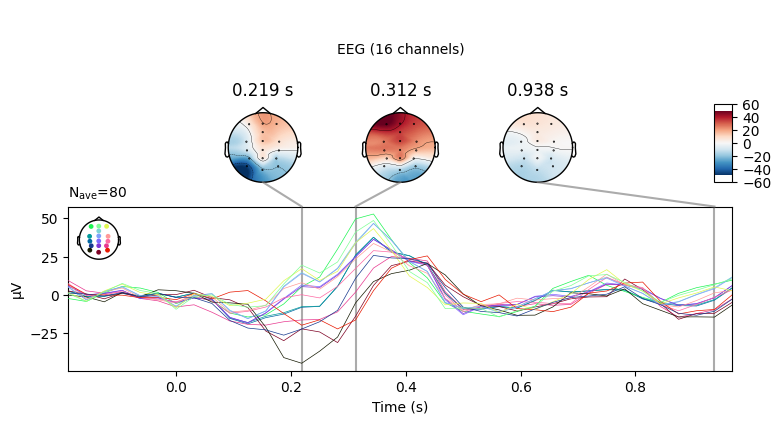

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train=='Target'
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test=='Target'

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [8]:
from hoda.hoda import BTTDA

block_rank=3
hoda = BTTDA(
    block_rank=block_rank,
    hoda_params=dict(
        max_iter=128,
        rank=(3,3),
        tol=1e-6,
        init ='ones',
        verbose=True,
        shrinkage=('oas', 'oas'),
        toeplitz=(1,),
        solver='ratio_svd'
    ),
    verbose=True
)

hoda.fit(X_train,y_train)

Fitting block 1/3 ...


  0%|          | 0/128 [00:00<?, ?it/s]

Tolerance reached
Fitting block 2/3 ...


  0%|          | 0/128 [00:00<?, ?it/s]

Tolerance reached
Fitting block 3/3 ...


  0%|          | 0/128 [00:00<?, ?it/s]

Tolerance reached


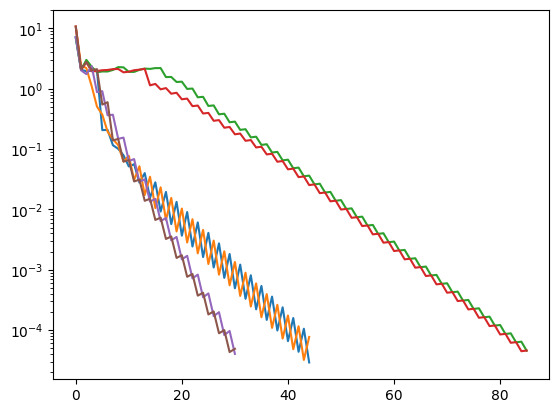

In [9]:
import cupy

for b in range(block_rank):
    plt.semilogy(cupy.asnumpy(hoda.blocks_[b].updates_))
plt.show()

No projector specified for this dataset. Please consider the method self.add_proj.


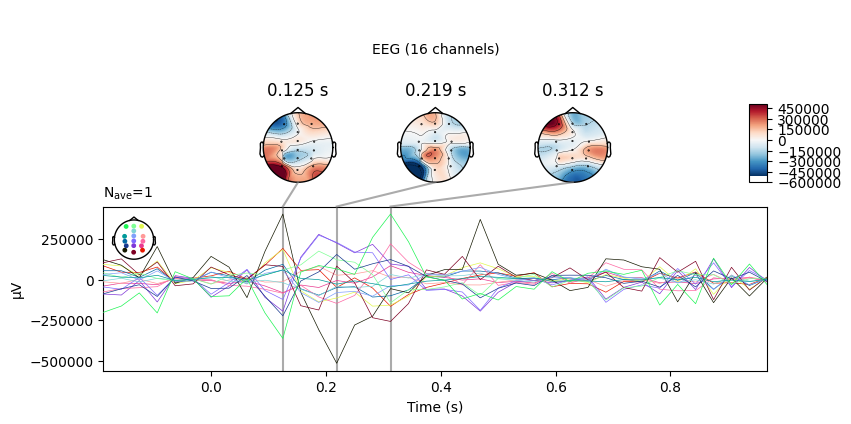

No projector specified for this dataset. Please consider the method self.add_proj.


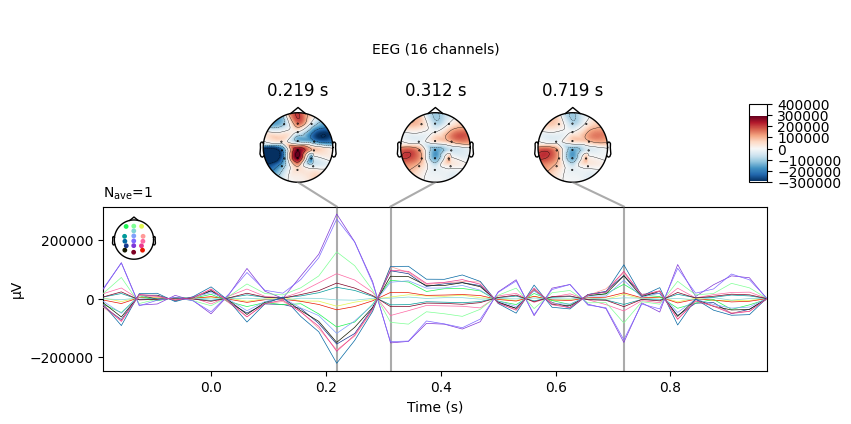

No projector specified for this dataset. Please consider the method self.add_proj.


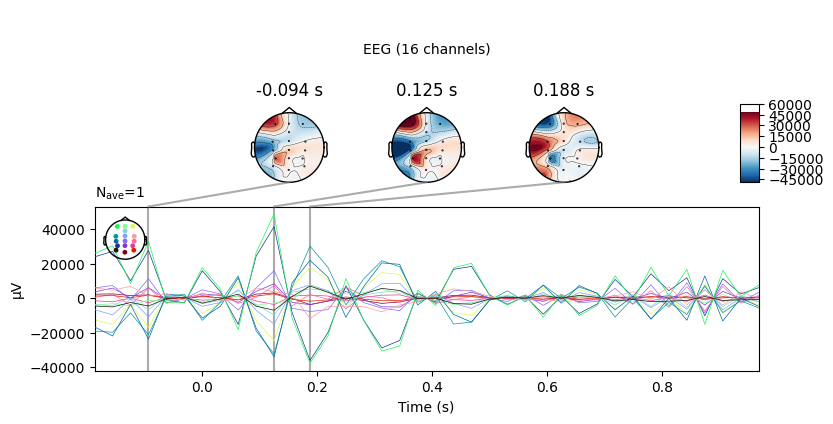

In [10]:
from mne import EvokedArray

for i in range(block_rank):
    core = hoda.blocks_[i].transform(X_train)
    core = core[y_train].mean(axis=0)-core[~y_train].mean(axis=0)
    w_sp = hoda.blocks_[i].projs_[0].squeeze()
    w_tmp = hoda.blocks_[i].projs_[1].squeeze()
    w = cupy.asnumpy(w_sp) @ core @ cupy.asnumpy(w_tmp.T)
    w = EvokedArray(w, epochs.info, epochs.tmin)
    w.plot_joint()
    #w.plot_image()

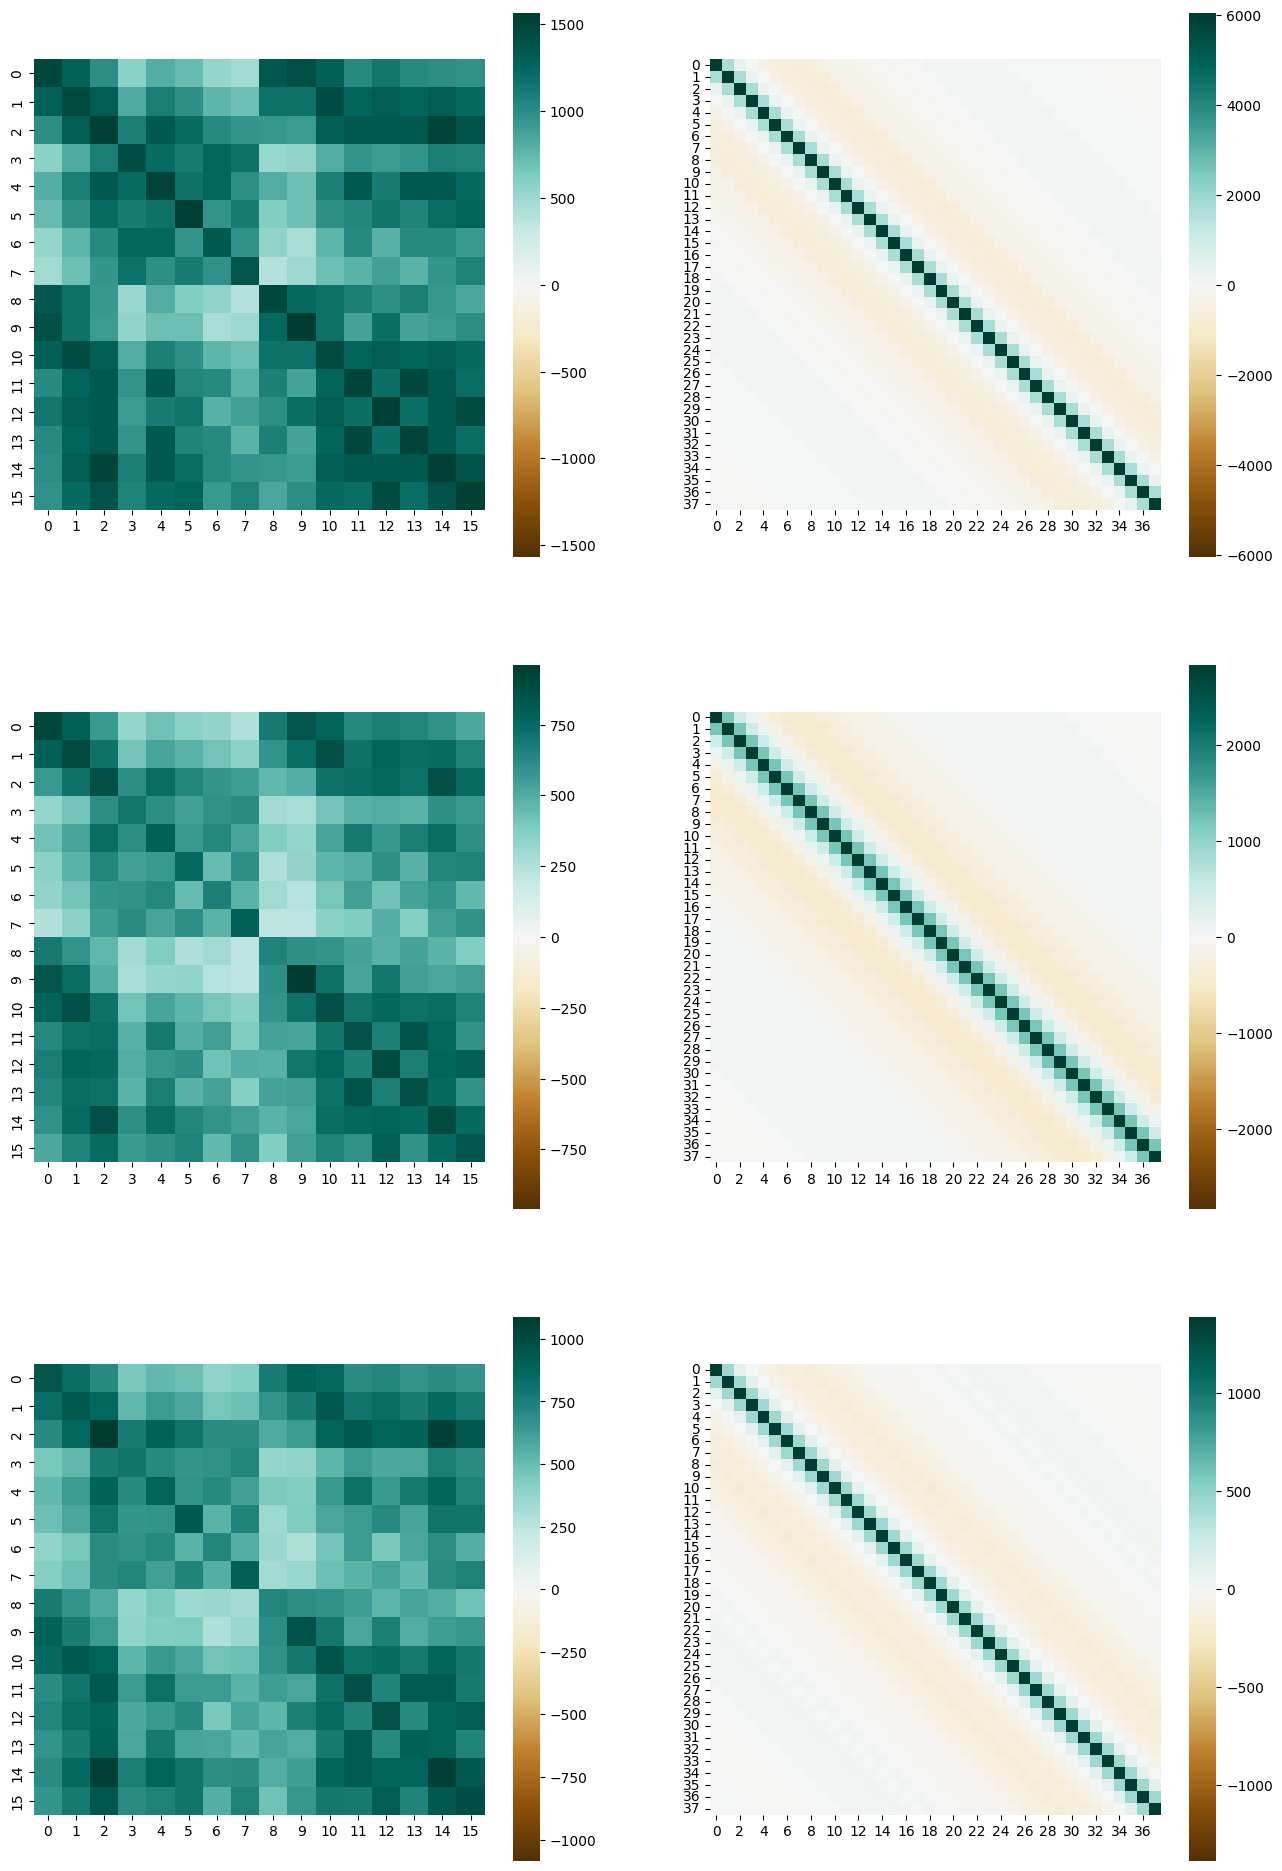

In [11]:
fig, axs = plt.subplots(block_rank,2, figsize=(16,8*block_rank))
axs = np.atleast_2d(axs)
for b in range(block_rank):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_w_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')

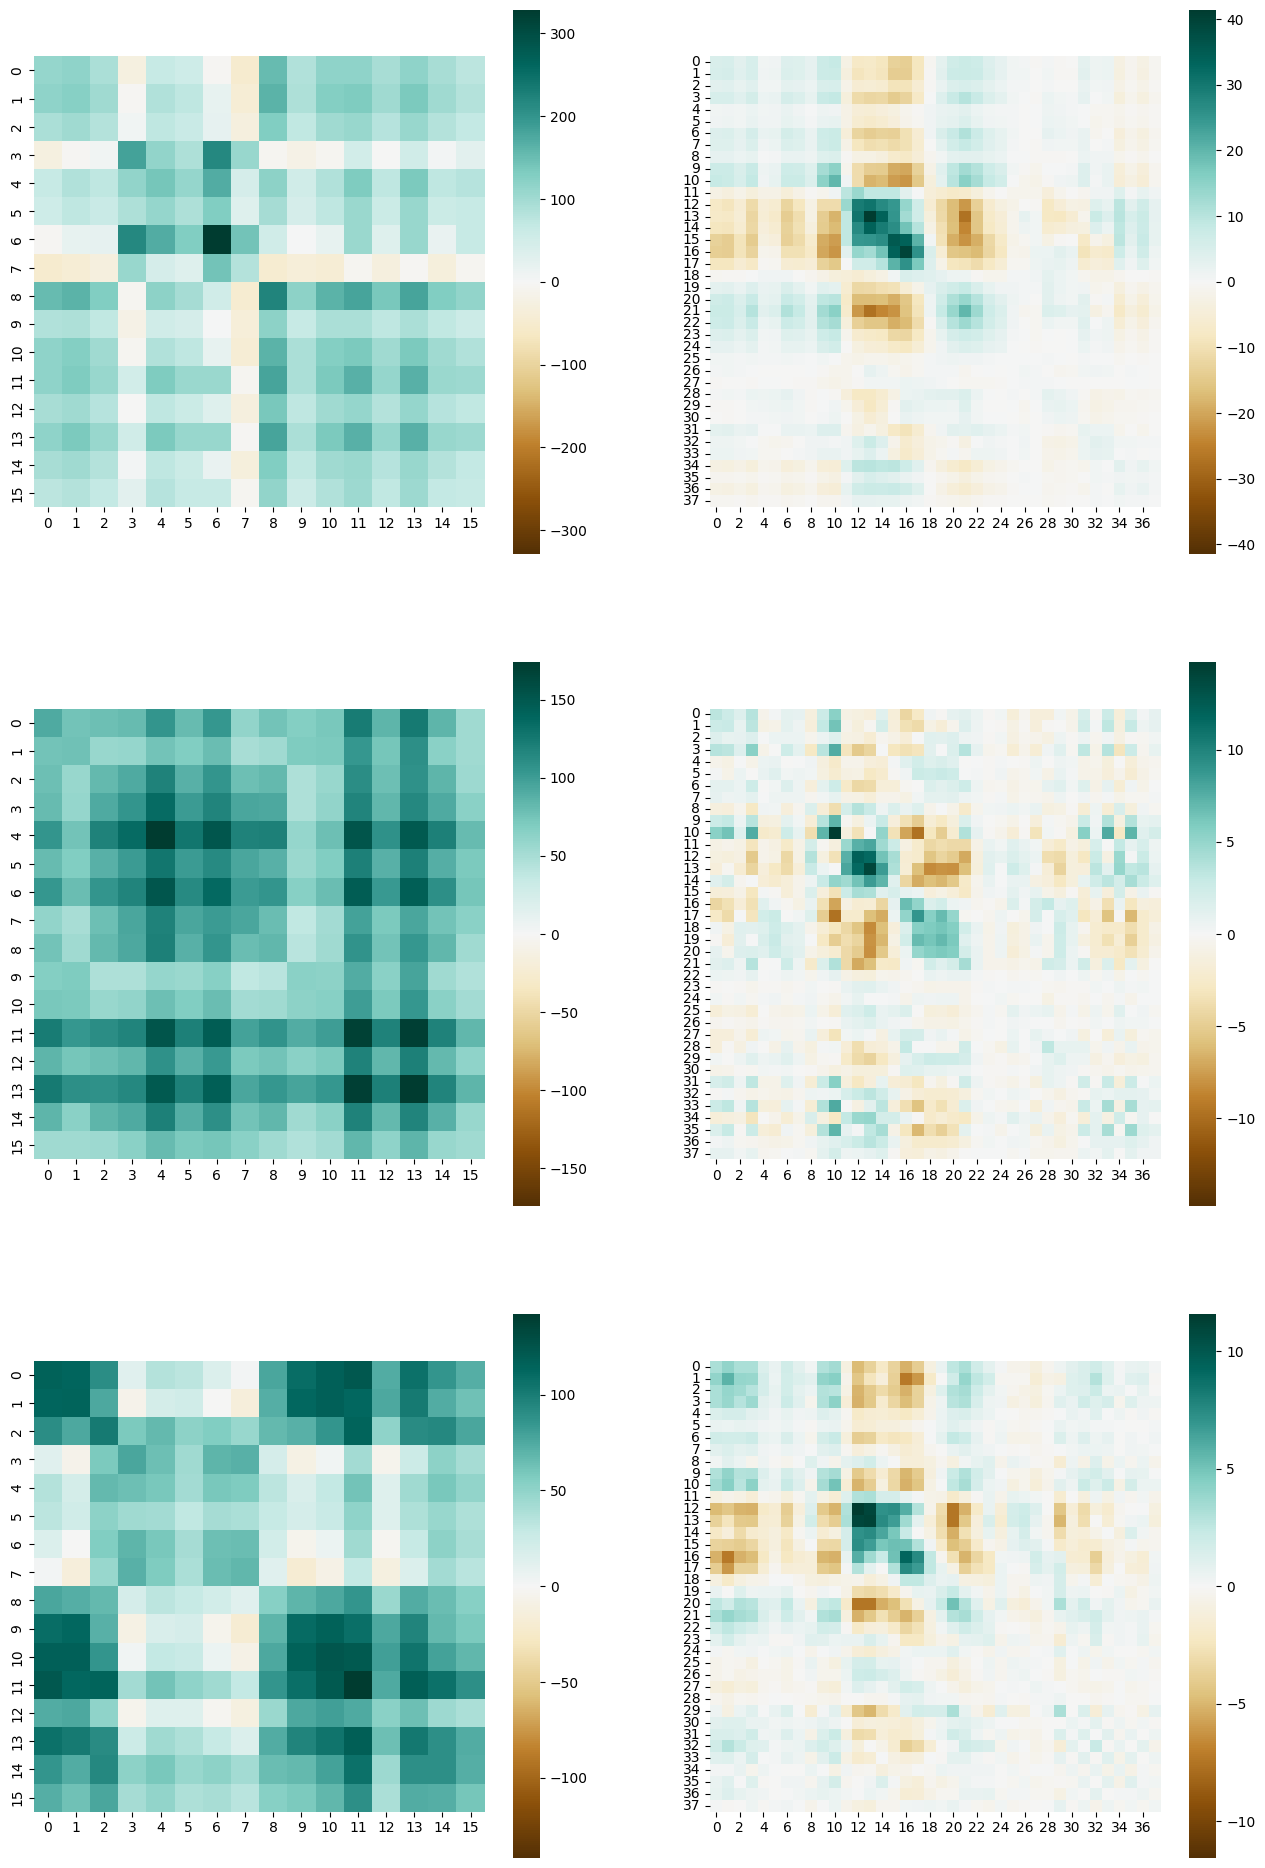

In [12]:
fig, axs = plt.subplots(block_rank,2, figsize=(16,8*block_rank))
axs = np.atleast_2d(axs)
for b in range(block_rank):
    for k in range(2):
        cov = cupy.asnumpy(hoda.blocks_[b].scatter_b_[k])
        vmax = np.max(np.abs(cov))
        sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[b,k])
        axs[b,k].set_aspect('equal')

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


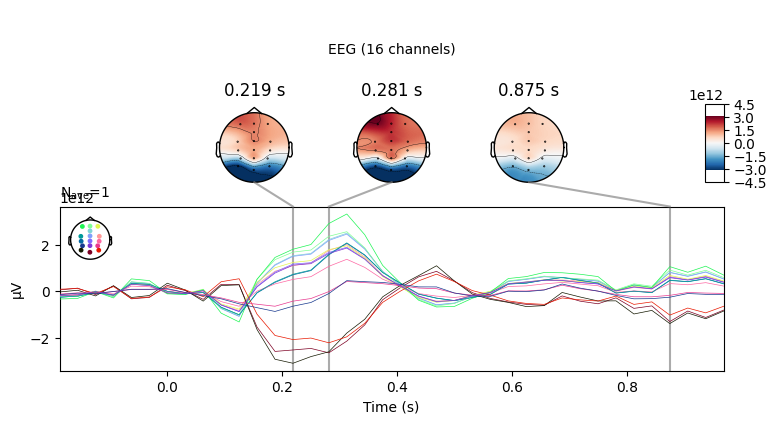

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


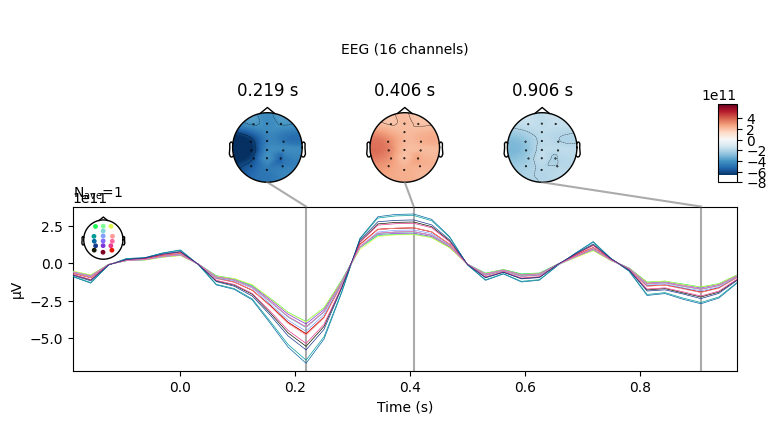

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


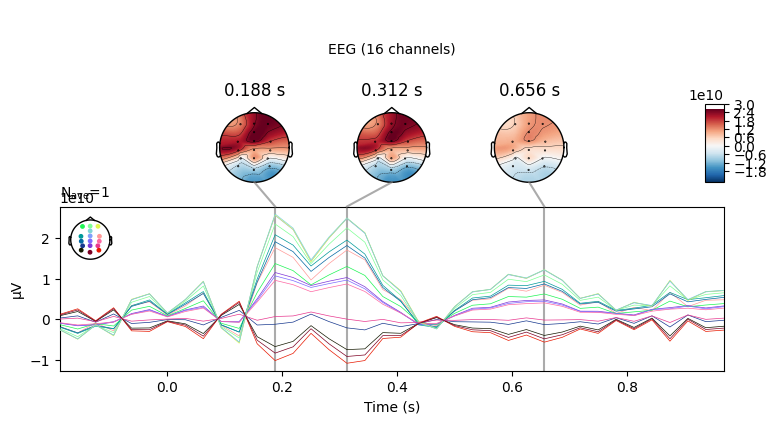

In [13]:
for i in range(block_rank):
    core = hoda.blocks_[i].transform(X_train)
    core = core[y_train].mean(axis=0)-core[~y_train].mean(axis=0)
    w_sp = hoda.blocks_[i].projs_[0].squeeze()
    w_tmp = hoda.blocks_[i].projs_[1].squeeze()
    ap_sp = hoda.blocks_[i].scatter_w_[0] @ w_sp
    ap_tmp = hoda.blocks_[i].scatter_w_[1] @ w_tmp
    ap = cupy.asnumpy(ap_sp) @ core @ cupy.asnumpy(ap_tmp.T)
    ap = EvokedArray(ap, epochs.info, epochs.tmin)
    ap.apply_baseline((-0.2, 0))
    ap.plot_joint()

In [14]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [16]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

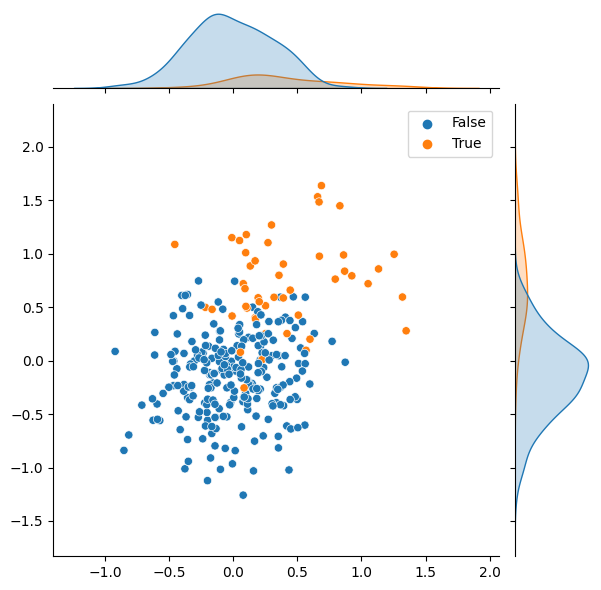

In [17]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [18]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9939236111111112

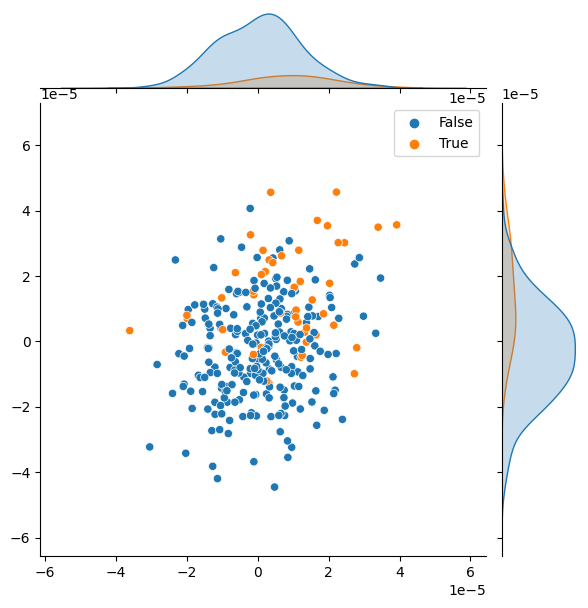

In [19]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [20]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.9387152777777777